# 12 - OLS y efectos temporales (`v2`)

Esta notebook estudia el eje temporal de los *fixed effects* en OLS.

La pregunta no es simplemente si agregar dummies de tiempo mejora el `R²`. La pregunta es más precisa:

> ¿Existe estructura temporal residual después de controlar por características observables, y qué parte corresponde a año, trimestre o celdas año×trimestre?

La versión `v2` reorganiza la notebook alrededor de una idea central:

- Los *fixed effects* temporales agregan poca performance global.
- Pero revelan y corrigen estructura temporal residual.
- Año domina a trimestre.
- `year + quarter FE` corrige márgenes temporales, pero no interacciones año×trimestre.
- La trayectoria año-trimestre no parece ruido puro: puede estar vinculada a dinámica macro, deflactación, composición muestral, shocks laborales, cambios de encuesta o cobertura.

Por diseño, esta notebook evita gráficos agregados de pocos números. Esos resultados van en tablas. Las figuras se reservan para fenómenos visuales: residuales temporales, heatmaps año×trimestre y evolución observada vs predicha.

## 00. Setup y descubrimiento de runs

La notebook consume artifacts producidos por el backend. No entrena modelos.

Layout esperado:

```text
reports/runs/<run_id>/
  metrics/model_comparison.csv
  predictions/validation_predictions.parquet
  predictions/test_predictions.parquet
  diagnostics/*fixed_effect*coefficients*.csv
  feature_columns.json
  dataset_card.json
  config_used.yaml
```

Los outputs de esta versión se escriben en:

```text
reports/notebook_outputs/ols_temporal_effects_v2/
```

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

try:
    import yaml
except ImportError:
    yaml = None


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/home/matias/repos/income-modeling-eph'),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / 'reports' / 'runs').exists()),
    Path('/home/matias/repos/income-modeling-eph'),
)

RUNS_DIR = ROOT / 'reports' / 'runs'
DATASET_PATH = ROOT / 'data' / 'processed' / 'modeling_dataset.parquet'

OUTPUT_DIR = ROOT / 'reports' / 'notebook_outputs' / 'ols_temporal_effects_v2'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 160)

print('ROOT:', ROOT)
print('RUNS_DIR:', RUNS_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8'))


def read_yaml_if_exists(path: Path):
    if not path.exists() or yaml is None:
        return None
    return yaml.safe_load(path.read_text(encoding='utf-8'))


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_parquet(path)


def fmt(x, digits=4):
    if pd.isna(x):
        return 'NA'
    return f'{x:.{digits}f}'

ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_temporal_effects_v2


## 01. Especificaciones y etiquetas canónicas

La comparación temporal usa cuatro especificaciones:

1. `ols_core`: benchmark OLS core actual.
2. `ols_core_year_fe`: core + *year fixed effects*.
3. `ols_core_quarter_fe`: core + *quarter fixed effects*.
4. `ols_core_year_plus_quarter_fe`: core + year FE + quarter FE, de forma aditiva.

Importante: `year + quarter FE` no es un modelo con dummies año×trimestre. Sólo permite efectos marginales de año y trimestre.

In [2]:
RUN_PATTERNS = {
    'ols_core': 'ols_core_*',
    'ols_core_year_fe': 'ols_core_year_fe_*',
    'ols_core_quarter_fe': 'ols_core_quarter_fe_*',
    'ols_core_year_plus_quarter_fe': 'ols_core_year_plus_quarter_fe_*',
}

ORDER = [
    'ols_core',
    'ols_core_year_fe',
    'ols_core_quarter_fe',
    'ols_core_year_plus_quarter_fe',
]

DISPLAY_LABELS = {
    'ols_core': 'Core OLS',
    'ols_core_year_fe': '+ Año FE',
    'ols_core_quarter_fe': '+ Trimestre FE',
    'ols_core_year_plus_quarter_fe': '+ Año + trimestre FE',
}

FE_LABELS = {
    'ols_core': 'Sin FE temporal',
    'ols_core_year_fe': 'Año',
    'ols_core_quarter_fe': 'Trimestre',
    'ols_core_year_plus_quarter_fe': 'Año + trimestre',
}

ORDER_INDEX = {exp: i for i, exp in enumerate(ORDER)}

# Si config_used.yaml no está disponible, esta exclusión evita que el patrón amplio
# ols_core_* capture por accidente runs de year/quarter FE.
CHILD_PREFIXES = {
    'ols_core': [
        'ols_core_year_fe_',
        'ols_core_quarter_fe_',
        'ols_core_year_plus_quarter_fe_',
    ],
}


def candidate_matches_experiment(candidate: Path, experiment: str) -> bool:
    config = read_yaml_if_exists(candidate / 'config_used.yaml') or {}
    experiment_id = ((config.get('experiment') or {}).get('id'))
    if experiment_id:
        return experiment_id == experiment

    name = candidate.name
    if not name.startswith(f'{experiment}_'):
        return False
    for child_prefix in CHILD_PREFIXES.get(experiment, []):
        if name.startswith(child_prefix):
            return False
    return True


def discover_runs() -> dict[str, Path | None]:
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        candidates = [p for p in candidates if candidate_matches_experiment(p, experiment)]
        runs[experiment] = candidates[-1] if candidates else None
    return runs


RUNS = discover_runs()

run_table = pd.DataFrame([
    {
        'experiment': exp,
        'label': DISPLAY_LABELS.get(exp, exp),
        'run_dir': str(path) if path else None,
        'found': path is not None,
    }
    for exp, path in RUNS.items()
])

run_table

,experiment,label,run_dir,found
0,ols_core,Core OLS,/home/matias/repos/income-modeling-eph/reports...,True
1,ols_core_year_fe,+ Año FE,/home/matias/repos/income-modeling-eph/reports...,True
2,ols_core_quarter_fe,+ Trimestre FE,/home/matias/repos/income-modeling-eph/reports...,True
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,/home/matias/repos/income-modeling-eph/reports...,True


## 02. Carga de artifacts

Se cargan métricas, predicciones y metadata. Las figuras principales de esta notebook dependen de predicciones individuales: necesitamos observar residuales por año, trimestre y celda año×trimestre.

In [3]:
def load_model_comparison(run_dir: Path, experiment: str) -> pd.DataFrame:
    df = read_csv_if_exists(run_dir / 'metrics' / 'model_comparison.csv')
    if df.empty:
        return df
    df = df.copy()
    df['experiment'] = experiment
    df['run_dir'] = str(run_dir)
    return df


def load_predictions(run_dir: Path, experiment: str, split: str) -> pd.DataFrame:
    path = run_dir / 'predictions' / f'{split}_predictions.parquet'
    df = read_parquet_if_exists(path)
    if df.empty:
        return df

    df = df.copy()
    df['experiment'] = experiment
    df['run_dir'] = str(run_dir)
    df['split'] = split

    required = {'y_true', 'y_pred'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Predictions for {experiment}/{split} miss columns: {missing}')

    df['residual'] = df['y_true'] - df['y_pred']
    df['abs_error'] = df['residual'].abs()
    df['squared_error'] = df['residual'] ** 2

    return df


def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / 'feature_columns.json') or []
    dataset_card = read_json_if_exists(run_dir / 'dataset_card.json') or {}
    config_used = read_yaml_if_exists(run_dir / 'config_used.yaml') or {}
    feature_view = config_used.get('feature_view') or {}
    fixed_effects = (config_used.get('model_design') or {}).get('fixed_effects') or []

    return {
        'experiment': experiment,
        'label': DISPLAY_LABELS.get(experiment, experiment),
        'run_dir': str(run_dir),
        'n_feature_columns': len(feature_columns),
        'feature_view_name': feature_view.get('name'),
        'include_blocks': feature_view.get('include_blocks'),
        'fixed_effects_config': fixed_effects,
        'dataset_card': dataset_card,
        'config_used': config_used,
    }


model_comparison_parts = []
prediction_parts = []
metadata_rows = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    model_comparison_parts.append(load_model_comparison(run_dir, experiment))
    for split in ['validation', 'test']:
        prediction_parts.append(load_predictions(run_dir, experiment, split))
    metadata_rows.append(load_run_metadata(run_dir, experiment))

model_comparison = (
    pd.concat([d for d in model_comparison_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in model_comparison_parts)
    else pd.DataFrame()
)

predictions = (
    pd.concat([d for d in prediction_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in prediction_parts)
    else pd.DataFrame()
)

run_metadata = pd.DataFrame(metadata_rows)

print('model_comparison:', model_comparison.shape)
print('predictions:', predictions.shape)
print('run_metadata:', run_metadata.shape)

if run_metadata.empty:
    raise RuntimeError('No se encontraron runs temporales. Revisar RUN_PATTERNS y reports/runs/.')

run_metadata[['experiment', 'label', 'feature_view_name', 'fixed_effects_config', 'n_feature_columns']]

model_comparison: (4, 14)
predictions: (240000, 12)
run_metadata: (4, 9)


,experiment,label,feature_view_name,fixed_effects_config,n_feature_columns
0,ols_core,Core OLS,linear_core,[],28
1,ols_core_year_fe,+ Año FE,linear_core_year_fe,"[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",29
2,ols_core_quarter_fe,+ Trimestre FE,linear_core_quarter_fe,"[{'name': 'quarter_fe', 'columns': ['TRIMESTRE...",29
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,linear_core_year_plus_quarter_fe,"[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",30


## 03. Enriquecimiento con año y trimestre

Las predicciones se enriquecen con `ANO4` y `TRIMESTRE`. Si esas columnas ya vienen en las predicciones, se usan directamente. Si no, se recuperan desde `data/processed/modeling_dataset.parquet` mediante `row_id`.

In [4]:
if predictions.empty:
    raise RuntimeError(
        'No se cargaron predicciones. Ejecutar primero los experimentos OLS temporales o revisar los paths.'
    )

pred_time = predictions.copy()

if not {'ANO4', 'TRIMESTRE'}.issubset(pred_time.columns):
    if 'row_id' not in pred_time.columns:
        raise ValueError('Las predicciones no tienen ANO4/TRIMESTRE ni row_id para mergear con el dataset.')
    if not DATASET_PATH.exists():
        raise FileNotFoundError(f'No se encontró el dataset procesado: {DATASET_PATH}')

    time_cols = ['row_id', 'ANO4', 'TRIMESTRE']
    dataset_time = pd.read_parquet(DATASET_PATH, columns=time_cols)
    pred_time = pred_time.merge(dataset_time, on='row_id', how='left', validate='many_to_one')

missing_time = pred_time[['ANO4', 'TRIMESTRE']].isna().any(axis=1).sum()
if missing_time:
    raise ValueError(f'Hay {missing_time} filas sin ANO4/TRIMESTRE después del merge.')

pred_time['ANO4'] = pred_time['ANO4'].astype(int)
pred_time['TRIMESTRE'] = pred_time['TRIMESTRE'].astype(int)
pred_time['period_order'] = pred_time['ANO4'] * 10 + pred_time['TRIMESTRE']
pred_time['year_quarter'] = pred_time['ANO4'].astype(str) + 'T' + pred_time['TRIMESTRE'].astype(str)

pred_time[['experiment', 'split', 'ANO4', 'TRIMESTRE', 'year_quarter', 'y_true', 'y_pred', 'residual']].head()

,experiment,split,ANO4,TRIMESTRE,year_quarter,y_true,y_pred,residual
0,ols_core,validation,2022,3,2022T3,3.484442,3.554492,-0.070050
1,ols_core,validation,2022,4,2022T4,3.735759,3.783123,-0.047365
2,ols_core,validation,2022,1,2022T1,3.680789,3.504383,0.176406
3,ols_core,validation,2022,1,2022T1,3.525822,3.553849,-0.028027
4,ols_core,validation,2022,1,2022T1,3.856850,3.697136,0.159713


## 04. Tabla principal de performance temporal

Esta tabla reemplaza al barplot de `ΔR²`. Hay pocos valores agregados, y la tabla comunica mejor.

La interpretación esperada no es “el mejor modelo gana”, sino:

> La mejora global es pequeña; año concentra casi todo el aporte temporal; trimestre agrega poco; año+trimestre apenas mejora sobre año solo.

In [5]:
def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def aggregate_metrics(g):
    y = g['y_true'].astype(float)
    yhat = g['y_pred'].astype(float)
    residual = y - yhat
    sd_y = y.std()
    return pd.Series({
        'n': len(g),
        'r2': safe_r2(y, yhat),
        'mae': residual.abs().mean(),
        'rmse': np.sqrt((residual ** 2).mean()),
        'mean_residual': residual.mean(),
        'sd_y_true': sd_y,
        'sd_y_pred': yhat.std(),
        'compression_ratio': yhat.std() / sd_y if sd_y else np.nan,
    })


metrics_by_split = (
    pred_time
    .groupby(['experiment', 'split'])
    .apply(aggregate_metrics)
    .reset_index()
)

metrics_by_split['experiment_order'] = metrics_by_split['experiment'].map(ORDER_INDEX)
metrics_by_split['label'] = metrics_by_split['experiment'].map(DISPLAY_LABELS)
metrics_by_split['fe_incluidos'] = metrics_by_split['experiment'].map(FE_LABELS)

validation_summary = (
    metrics_by_split
    .query("split == 'validation'")
    .sort_values('experiment_order')
    .reset_index(drop=True)
)

core = validation_summary.query("experiment == 'ols_core'")
if core.empty:
    raise RuntimeError('No está ols_core en validation_summary; no se pueden calcular deltas vs core.')

core = core.iloc[0]
for col in ['r2', 'mae', 'rmse', 'compression_ratio']:
    validation_summary[f'delta_{col}_vs_core'] = validation_summary[col] - core[col]

metrics_by_split.to_csv(TABLE_DIR / 'T1_ols_temporal_metrics_by_split.csv', index=False)
validation_summary.to_csv(TABLE_DIR / 'T2_ols_temporal_validation_vs_core.csv', index=False)
run_metadata.to_csv(TABLE_DIR / 'T3_ols_temporal_run_metadata.csv', index=False)

cols = [
    'label', 'fe_incluidos', 'n',
    'r2', 'delta_r2_vs_core',
    'mae', 'delta_mae_vs_core',
    'rmse', 'delta_rmse_vs_core',
    'compression_ratio', 'delta_compression_ratio_vs_core',
]

validation_summary[cols].round(5)

,label,fe_incluidos,n,r2,delta_r2_vs_core,mae,delta_mae_vs_core,rmse,delta_rmse_vs_core,compression_ratio,delta_compression_ratio_vs_core
0,Core OLS,Sin FE temporal,20000.0,0.40193,0.00000,0.21663,0.00000,0.29189,0.00000,0.62909,0.00000
1,+ Año FE,Año,20000.0,0.40834,0.00641,0.21547,-0.00116,0.29032,-0.00157,0.63372,0.00463
2,+ Trimestre FE,Trimestre,20000.0,0.40306,0.00113,0.21632,-0.00031,0.29161,-0.00028,0.63018,0.00109
3,+ Año + trimestre FE,Año + trimestre,20000.0,0.40885,0.00692,0.21531,-0.00132,0.29020,-0.00169,0.63445,0.00537


## 05. Resúmenes temporales de residuales

Los residuales se agregan por:

- año;
- trimestre;
- celda año×trimestre.

Estos resúmenes permiten separar tres capas:

1. deriva anual;
2. estacionalidad trimestral;
3. shocks o estructura específica de celda año×trimestre.

In [6]:
def temporal_group_summary(df, group_cols):
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    out = (
        df
        .groupby(['experiment', 'split'] + group_cols, as_index=False)
        .agg(
            n=('y_true', 'size'),
            mean_y_true=('y_true', 'mean'),
            mean_y_pred=('y_pred', 'mean'),
            mean_residual=('residual', 'mean'),
            mae=('abs_error', 'mean'),
            rmse=('squared_error', lambda s: np.sqrt(np.mean(s))),
        )
    )
    return out


year_summary = temporal_group_summary(pred_time, 'ANO4').sort_values(['experiment', 'split', 'ANO4'])
quarter_summary = temporal_group_summary(pred_time, 'TRIMESTRE').sort_values(['experiment', 'split', 'TRIMESTRE'])
year_quarter_summary = temporal_group_summary(pred_time, ['ANO4', 'TRIMESTRE', 'year_quarter', 'period_order'])
year_quarter_summary = year_quarter_summary.sort_values(['experiment', 'split', 'period_order'])

year_summary.to_csv(TABLE_DIR / 'T4_ols_temporal_residual_by_year.csv', index=False)
quarter_summary.to_csv(TABLE_DIR / 'T5_ols_temporal_residual_by_quarter.csv', index=False)
year_quarter_summary.to_csv(TABLE_DIR / 'T6_ols_temporal_residual_by_year_quarter.csv', index=False)

# Tabla compacta de rangos: cuánto sesgo medio temporal queda por grupo.
def residual_range(df, group_name):
    return (
        df.query("split == 'validation'")
        .groupby('experiment', as_index=False)
        .agg(
            min_mean_residual=('mean_residual', 'min'),
            max_mean_residual=('mean_residual', 'max'),
        )
        .assign(
            residual_range=lambda d: d['max_mean_residual'] - d['min_mean_residual'],
            group=group_name,
            label=lambda d: d['experiment'].map(DISPLAY_LABELS),
        )
        .sort_values('experiment', key=lambda s: s.map(ORDER_INDEX))
    )

range_summary = pd.concat([
    residual_range(year_summary, 'Año'),
    residual_range(quarter_summary, 'Trimestre'),
    residual_range(year_quarter_summary, 'Año×trimestre'),
], ignore_index=True)

range_summary.to_csv(TABLE_DIR / 'T7_ols_temporal_residual_ranges.csv', index=False)
range_summary[['group', 'label', 'min_mean_residual', 'max_mean_residual', 'residual_range']].round(5)

,group,label,min_mean_residual,max_mean_residual,residual_range
0,Año,Core OLS,-0.04242,0.06562,0.10804
1,Año,+ Año FE,-0.00646,0.00320,0.00967
2,Año,+ Trimestre FE,-0.04127,0.05316,0.09443
3,Año,+ Año + trimestre FE,-0.00605,0.00295,0.00900
4,Trimestre,Core OLS,-0.02137,0.01105,0.03242
5,Trimestre,+ Año FE,-0.01558,0.01001,0.02559
6,Trimestre,+ Trimestre FE,-0.00635,-0.00031,0.00605
7,Trimestre,+ Año + trimestre FE,-0.00707,0.00045,0.00751
8,Año×trimestre,Core OLS,-0.09143,0.06562,0.15705
9,Año×trimestre,+ Año FE,-0.05568,0.05726,0.11294


## 06. Figura 1 — residuales medios marginales por año y trimestre

Esta figura conserva la información útil de los plots originales por año y trimestre, pero evita dos figuras débiles separadas.

La lectura buscada es:

- el core tiene deriva temporal residual;
- la deriva anual es mayor que la estacionalidad trimestral;
- los FE reducen fuertemente el sesgo medio de los grupos incluidos;
- la corrección de márgenes puede ser grande aunque el `R²` global cambie poco.

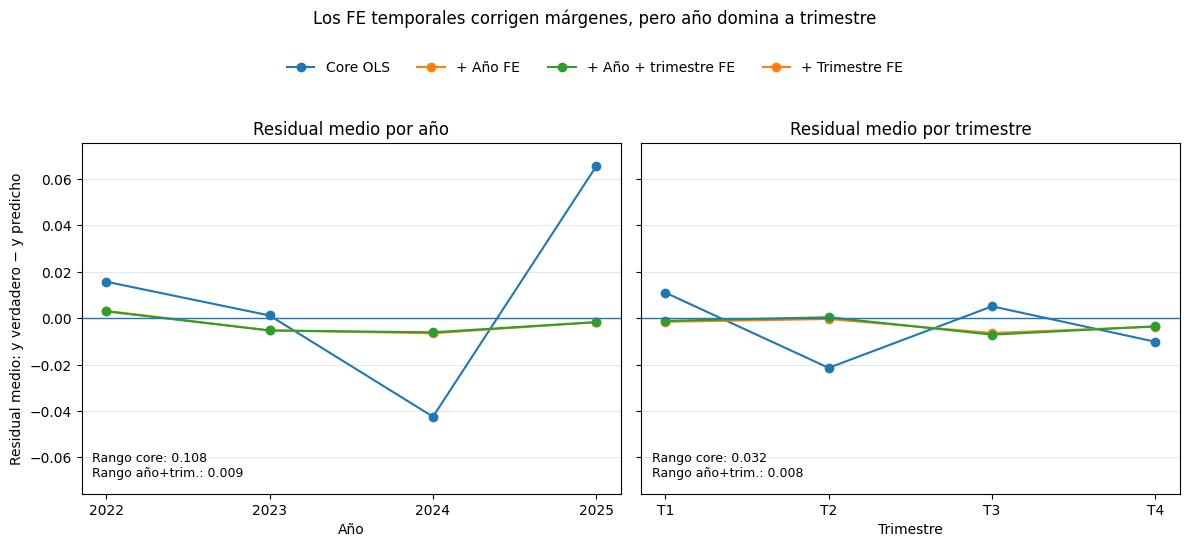

In [7]:
def residual_range_for(df, experiment):
    tmp = df.query("split == 'validation' and experiment == @experiment")
    if tmp.empty:
        return np.nan
    return tmp['mean_residual'].max() - tmp['mean_residual'].min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# Escala común para comparar magnitudes entre año y trimestre.
combined = pd.concat([
    year_summary.query("split == 'validation'"),
    quarter_summary.query("split == 'validation'"),
], ignore_index=True)
y_abs = combined['mean_residual'].abs().max()
y_pad = max(0.01, y_abs * 0.15)
y_lim = (-y_abs - y_pad, y_abs + y_pad)

# Panel A: año.
ax = axes[0]
for experiment in ['ols_core', 'ols_core_year_fe', 'ols_core_year_plus_quarter_fe']:
    tmp = year_summary.query("split == 'validation' and experiment == @experiment").sort_values('ANO4')
    if tmp.empty:
        continue
    ax.plot(tmp['ANO4'].astype(str), tmp['mean_residual'], marker='o', label=DISPLAY_LABELS[experiment])
ax.axhline(0, linewidth=1)
ax.set_title('Residual medio por año')
ax.set_xlabel('Año')
ax.set_ylabel('Residual medio: y verdadero − y predicho')
ax.set_ylim(y_lim)
ax.grid(axis='y', alpha=0.3)
core_range = residual_range_for(year_summary, 'ols_core')
yq_range = residual_range_for(year_summary, 'ols_core_year_plus_quarter_fe')
ax.text(
    0.02, 0.04,
    f'Rango core: {fmt(core_range, 3)}\nRango año+trim.: {fmt(yq_range, 3)}',
    transform=ax.transAxes,
    fontsize=9,
    va='bottom',
)

# Panel B: trimestre.
ax = axes[1]
for experiment in ['ols_core', 'ols_core_quarter_fe', 'ols_core_year_plus_quarter_fe']:
    tmp = quarter_summary.query("split == 'validation' and experiment == @experiment").sort_values('TRIMESTRE')
    if tmp.empty:
        continue
    ax.plot('T' + tmp['TRIMESTRE'].astype(str), tmp['mean_residual'], marker='o', label=DISPLAY_LABELS[experiment])
ax.axhline(0, linewidth=1)
ax.set_title('Residual medio por trimestre')
ax.set_xlabel('Trimestre')
ax.set_ylim(y_lim)
ax.grid(axis='y', alpha=0.3)
core_range_q = residual_range_for(quarter_summary, 'ols_core')
yq_range_q = residual_range_for(quarter_summary, 'ols_core_year_plus_quarter_fe')
ax.text(
    0.02, 0.04,
    f'Rango core: {fmt(core_range_q, 3)}\nRango año+trim.: {fmt(yq_range_q, 3)}',
    transform=ax.transAxes,
    fontsize=9,
    va='bottom',
)

handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels + labels2, handles + handles2))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Los FE temporales corrigen márgenes, pero año domina a trimestre', y=1.13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'F1_v2_residual_marginal_year_quarter.png', dpi=180, bbox_inches='tight')
plt.show()

## 07. Figura 2 — heatmap de residual medio por celda año×trimestre

El plot original como línea año-trimestre mezclaba demasiadas capas. El heatmap muestra mejor qué queda en cada celda.

Comparar `Core OLS` contra `+ Año + trimestre FE` permite ver el límite de la especificación aditiva:

```text
y = Xβ + δ_año + τ_trimestre + ε
```

Ese modelo corrige márgenes anuales y trimestrales, pero no contiene dummies año×trimestre.

/tmp/ipykernel_566178/1243897237.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


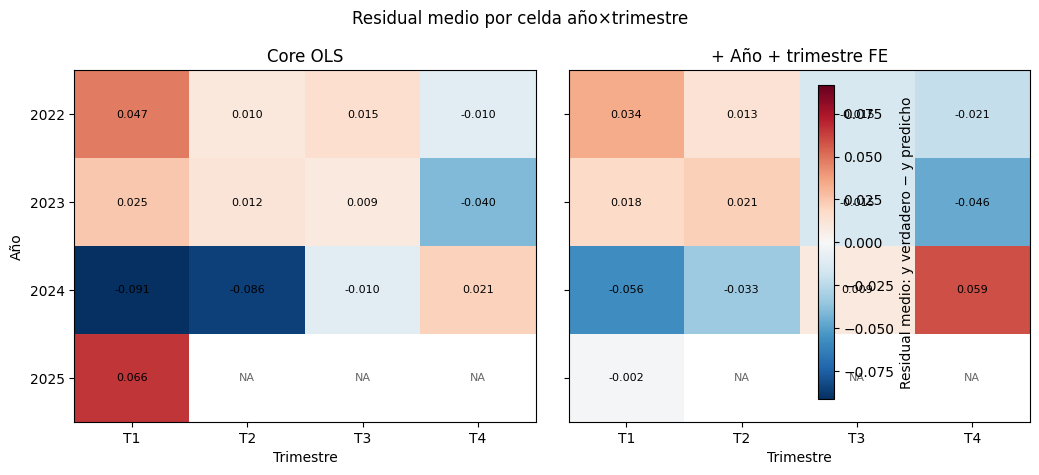

In [9]:
def make_year_quarter_matrix(summary_df, experiment):
    tmp = summary_df.query("split == 'validation' and experiment == @experiment").copy()
    years = sorted(tmp['ANO4'].dropna().astype(int).unique())
    quarters = [1, 2, 3, 4]
    mat = pd.DataFrame(index=years, columns=quarters, dtype=float)
    for _, row in tmp.iterrows():
        mat.loc[int(row['ANO4']), int(row['TRIMESTRE'])] = row['mean_residual']
    return mat

mat_core = make_year_quarter_matrix(year_quarter_summary, 'ols_core')
mat_yq = make_year_quarter_matrix(year_quarter_summary, 'ols_core_year_plus_quarter_fe')

vmax = np.nanmax(np.abs(pd.concat([mat_core.stack(), mat_yq.stack()])))
vmax = max(vmax, 1e-6)
norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad('white')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), sharex=True, sharey=True)

for ax, mat, title in [
    (axes[0], mat_core, 'Core OLS'),
    (axes[1], mat_yq, '+ Año + trimestre FE'),
]:
    arr = np.ma.masked_invalid(mat.to_numpy(dtype=float))
    im = ax.imshow(arr, cmap=cmap, norm=norm, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['T1', 'T2', 'T3', 'T4'])
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([str(y) for y in mat.index])
    ax.set_xlabel('Trimestre')

    for i, year in enumerate(mat.index):
        for j, quarter in enumerate(mat.columns):
            value = mat.loc[year, quarter]
            if pd.isna(value):
                ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, alpha=0.6)
            else:
                ax.text(j, i, f'{value:.3f}', ha='center', va='center', fontsize=8)

axes[0].set_ylabel('Año')
fig.suptitle('Residual medio por celda año×trimestre')
cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.03)
cbar.set_label('Residual medio: y verdadero − y predicho')
fig.tight_layout()
fig.savefig(FIG_DIR / 'F2_v2_heatmap_year_quarter_residual.png', dpi=180, bbox_inches='tight')
plt.show()

## 08. Figura 3 — media observada vs media predicha por año-trimestre

El residual medio de una celda es:

```text
mean(y_true) - mean(y_pred)
```

Por eso conviene mirar directamente las dos medias. Si `mean(y_true)` se mueve más que `mean(y_pred_core)`, el core está capturando composición observada pero no todo el nivel temporal del ingreso.

Esta figura aprovecha que año-trimestre sí tiene orden temporal real. Acá una línea sí está justificada.

In [10]:
plot_base = year_quarter_summary.query("split == 'validation'").copy()

# La media observada es la misma para todos los modelos; tomamos la serie del core como referencia.
observed = (
    plot_base.query("experiment == 'ols_core'")
    .sort_values('period_order')
    [['period_order', 'year_quarter', 'mean_y_true', 'n']]
    .drop_duplicates('period_order')
)

pred_core = (
    plot_base.query("experiment == 'ols_core'")
    .sort_values('period_order')
    [['period_order', 'mean_y_pred']]
    .rename(columns={'mean_y_pred': 'mean_pred_core'})
)

pred_yq = (
    plot_base.query("experiment == 'ols_core_year_plus_quarter_fe'")
    .sort_values('period_order')
    [['period_order', 'mean_y_pred']]
    .rename(columns={'mean_y_pred': 'mean_pred_year_quarter_fe'})
)

temporal_means = observed.merge(pred_core, on='period_order', how='left').merge(pred_yq, on='period_order', how='left')
temporal_means.to_csv(TABLE_DIR / 'T8_ols_temporal_means_observed_predicted_by_year_quarter.csv', index=False)

temporal_means

,period_order,year_quarter,mean_y_true,n,mean_pred_core,mean_pred_year_quarter_fe
0,20221,2022T1,3.717202,1594,3.669722,3.682950
1,20222,2022T2,3.669175,1550,3.659403,3.655952
2,20223,2022T3,3.670708,1584,3.655338,3.685231
3,20224,2022T4,3.646666,1562,3.656911,3.668142
4,20231,2023T1,3.664398,1543,3.639541,3.646575
5,20232,2023T2,3.658640,1585,3.646966,3.637204
6,20233,2023T3,3.659494,1551,3.650696,3.674081
7,20234,2023T4,3.586122,1557,3.626569,3.632071
8,20241,2024T1,3.551327,1533,3.642760,3.607777
9,20242,2024T2,3.555526,1566,3.641153,3.588970


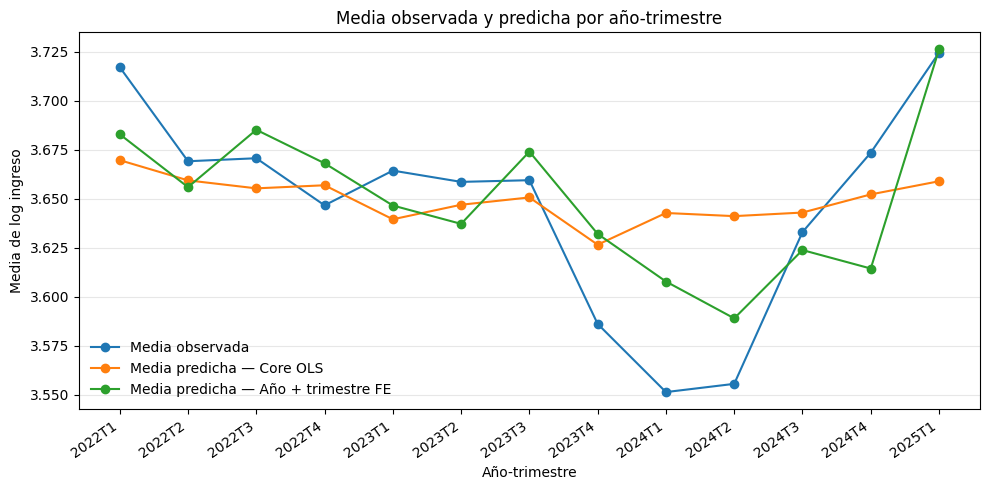

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(temporal_means))
labels = temporal_means['year_quarter'].tolist()

ax.plot(x, temporal_means['mean_y_true'], marker='o', label='Media observada')
ax.plot(x, temporal_means['mean_pred_core'], marker='o', label='Media predicha — Core OLS')
if temporal_means['mean_pred_year_quarter_fe'].notna().any():
    ax.plot(x, temporal_means['mean_pred_year_quarter_fe'], marker='o', label='Media predicha — Año + trimestre FE')

ax.set_title('Media observada y predicha por año-trimestre')
ax.set_xlabel('Año-trimestre')
ax.set_ylabel('Media de log ingreso')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'F3_v2_observed_predicted_means_year_quarter.png', dpi=180)
plt.show()

## 09. Coeficientes de fixed effects

Los coeficientes FE se reportan como tabla, no como gráfico. Son pocos números y su valor está en la interpretación.

Recordatorio:

> Un coeficiente FE no es una media cruda de ingreso. Es una diferencia ajustada respecto de una categoría omitida, después de controlar por las demás variables del modelo.

Además, si los coeficientes trimestrales cambian al agregar año FE, eso indica que la lectura “trimestre puro” era frágil: parte de lo que parecía trimestre estaba mezclado con composición temporal anual.

In [12]:
def find_fe_coefficient_files(run_dir: Path) -> list[Path]:
    diagnostics_dir = run_dir / 'diagnostics'
    if not diagnostics_dir.exists():
        return []
    patterns = [
        '*fixed_effect*coefficients*.csv',
        '*FixedEffect*coefficients*.csv',
        '*fe*coefficients*.csv',
    ]
    files = []
    for pattern in patterns:
        files.extend(diagnostics_dir.glob(pattern))
    return sorted(set(files))


fe_parts = []
for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    for path in find_fe_coefficient_files(run_dir):
        df = pd.read_csv(path)
        df['experiment'] = experiment
        df['label'] = DISPLAY_LABELS.get(experiment, experiment)
        df['source_file'] = str(path.relative_to(run_dir))
        fe_parts.append(df)

fe_coefficients = pd.concat(fe_parts, ignore_index=True) if fe_parts else pd.DataFrame()

if fe_coefficients.empty:
    print('No se encontraron archivos de coeficientes FE. Usar los diagnósticos de residuales por tiempo.')
else:
    fe_coefficients.to_csv(TABLE_DIR / 'T9_ols_temporal_fixed_effect_coefficients_raw.csv', index=False)
    display(fe_coefficients.head(80))

,run_id,model,fe_name,level,feature,coefficient,abs_coefficient,sign,rank,experiment,label,source_file
0,ols_core_year_fe_20260611T050813Z,LinearRegression,year_fe,2025,cat__fe_year_fe_2025,0.053916,0.053916,positive,1,ols_core_year_fe,+ Año FE,diagnostics/fixed_effect_coefficients.csv
1,ols_core_year_fe_20260611T050813Z,LinearRegression,year_fe,2024,cat__fe_year_fe_2024,-0.049777,0.049777,negative,2,ols_core_year_fe,+ Año FE,diagnostics/fixed_effect_coefficients.csv
2,ols_core_year_fe_20260611T050813Z,LinearRegression,year_fe,2023,cat__fe_year_fe_2023,-0.006941,0.006941,negative,3,ols_core_year_fe,+ Año FE,diagnostics/fixed_effect_coefficients.csv
3,ols_core_quarter_fe_20260611T050827Z,LinearRegression,quarter_fe,2,cat__fe_quarter_fe_2,-0.033697,0.033697,negative,1,ols_core_quarter_fe,+ Trimestre FE,diagnostics/fixed_effect_coefficients.csv
4,ols_core_quarter_fe_20260611T050827Z,LinearRegression,quarter_fe,4,cat__fe_quarter_fe_4,-0.019161,0.019161,negative,2,ols_core_quarter_fe,+ Trimestre FE,diagnostics/fixed_effect_coefficients.csv
5,ols_core_quarter_fe_20260611T050827Z,LinearRegression,quarter_fe,3,cat__fe_quarter_fe_3,-0.001120,0.001120,negative,3,ols_core_quarter_fe,+ Trimestre FE,diagnostics/fixed_effect_coefficients.csv
6,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,year_fe,2025,cat__fe_year_fe_2025,0.052922,0.052922,positive,1,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv
7,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,year_fe,2024,cat__fe_year_fe_2024,-0.050049,0.050049,negative,2,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv
8,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,year_fe,2023,cat__fe_year_fe_2023,-0.007039,0.007039,negative,3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv
9,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,quarter_fe,2,cat__fe_quarter_fe_2,-0.016926,0.016926,negative,1,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv


## 10. Confirmación de expectativas teóricas

Esta sección resume qué principios de los *fixed effects* se observan empíricamente en estos datos.

La idea no es decorar el análisis con teoría, sino usar la teoría como control de calidad:

1. **Los FE corrigen residuales medios del grupo incluido.**  
   Si hay dummies de año, el residual medio por año debería bajar fuertemente.

2. **Los FE marginales no eliminan interacciones.**  
   `year FE + quarter FE` no equivale a `year×quarter FE`.

3. **Quarter-only puede mezclar estructura anual.**  
   Si la muestra está desbalanceada temporalmente —por ejemplo, 2025 sólo tiene T1—, los coeficientes trimestrales deben interpretarse con cuidado.

In [13]:
def get_range(summary_df, experiment):
    tmp = summary_df.query("split == 'validation' and experiment == @experiment")
    if tmp.empty:
        return np.nan
    return tmp['mean_residual'].max() - tmp['mean_residual'].min()

core_year_range = get_range(year_summary, 'ols_core')
year_fe_year_range = get_range(year_summary, 'ols_core_year_fe')
yq_year_range = get_range(year_summary, 'ols_core_year_plus_quarter_fe')

core_quarter_range = get_range(quarter_summary, 'ols_core')
quarter_fe_quarter_range = get_range(quarter_summary, 'ols_core_quarter_fe')
yq_quarter_range = get_range(quarter_summary, 'ols_core_year_plus_quarter_fe')

core_yq_range = get_range(year_quarter_summary, 'ols_core')
yq_yq_range = get_range(year_quarter_summary, 'ols_core_year_plus_quarter_fe')

notes = [
    f'Year FE: rango de residual medio por año cae de {fmt(core_year_range, 5)} en core a {fmt(year_fe_year_range, 5)} con year FE.',
    f'Year+quarter FE: rango de residual medio por año queda en {fmt(yq_year_range, 5)}.',
    f'Quarter FE: rango de residual medio por trimestre cae de {fmt(core_quarter_range, 5)} en core a {fmt(quarter_fe_quarter_range, 5)} con quarter FE.',
    f'Year+quarter FE: rango de residual medio por trimestre queda en {fmt(yq_quarter_range, 5)}.',
    f'Año×trimestre: el rango por celda cae de {fmt(core_yq_range, 5)} en core a {fmt(yq_yq_range, 5)} con year+quarter FE, pero no desaparece porque el modelo no incluye interacciones año×trimestre.',
]

DIAGNOSTIC_SUMMARY = '\n'.join(f'- {note}' for note in notes)
print(DIAGNOSTIC_SUMMARY)

(TABLE_DIR / 'T10_ols_temporal_theoretical_checks.txt').write_text(DIAGNOSTIC_SUMMARY, encoding='utf-8')

- Year FE: rango de residual medio por año cae de 0.10804 en core a 0.00967 con year FE.
- Year+quarter FE: rango de residual medio por año queda en 0.00900.
- Quarter FE: rango de residual medio por trimestre cae de 0.03242 en core a 0.00605 con quarter FE.
- Year+quarter FE: rango de residual medio por trimestre queda en 0.00751.
- Año×trimestre: el rango por celda cae de 0.15705 en core a 0.11558 con year+quarter FE, pero no desaparece porque el modelo no incluye interacciones año×trimestre.


499

## 11. Interpretación para tesis

Los fixed effects temporales agregan poca capacidad predictiva global, pero revelan estructura temporal residual interpretable. La mayor parte del efecto temporal es anual: los residuales medios del core varían mucho más entre años que entre trimestres, y year FE captura casi todo el incremento de performance. Sin embargo, al mirar las celdas año×trimestre aparece una estructura temporal más rica, con un deterioro residual alrededor de 2024T1–2024T2 y una reversión posterior. El modelo year+quarter FE corrige los márgenes anuales y trimestrales, pero no puede capturar interacciones específicas año×trimestre.

Por lo tanto, el resultado temporal no debe leerse sólo como una pequeña mejora en `R²`, sino como evidencia de deriva temporal residual y de los límites de una especificación aditiva.

La confirmación teórica es el punto metodológico fuerte: en los datos, los FE reducen los residuales medios de los grupos incluidos, pero no eliminan estructuras que el diseño de la matriz no contiene.

## 12. Outputs escritos

Tablas:

```text
reports/notebook_outputs/ols_temporal_effects_v2/tables/
```

Figuras:

```text
reports/notebook_outputs/ols_temporal_effects_v2/figures/
```

Candidatas principales para tesis:

```text
T2_ols_temporal_validation_vs_core.csv
T7_ols_temporal_residual_ranges.csv
T8_ols_temporal_means_observed_predicted_by_year_quarter.csv
F1_v2_residual_marginal_year_quarter.png
F2_v2_heatmap_year_quarter_residual.png
F3_v2_observed_predicted_means_year_quarter.png
T10_ols_temporal_theoretical_checks.txt
```